In [1]:
import os
import pandas as pd
import re

In [2]:
def get_method_dict(file):
    method_dict = {'average' : 'average'}
    with open(file, 'r') as f:
        lines = [line.rstrip() for line in f.readlines()]
        i = 1
        for l in lines:
            match = re.search(r'^.+attrib=([^_]+)_mpd.+_thresh=([^_]+)_.+$', l)
            method = match.group(1)
            threshold = match.group(2)
            key = 'list' + str(i)
            method_dict[key] = method + '_' + threshold
            i += 1
    return method_dict

In [3]:
bcms_twitter_methods = get_method_dict('../../manual_eval/randomized_lists/randomized_lists.bcms_twitter.txt')

In [4]:
bcms_twitter_methods

{'average': 'average',
 'list1': 'lime_0.6',
 'list2': 'loo_0.1',
 'list3': 'shap_0.1',
 'list4': 'ig_0.6',
 'list5': 'loo_0.6',
 'list6': 'ig_0.1',
 'list7': 'shap_0.6',
 'list8': 'lime_0.1'}

In [5]:
bcms_twitter_methods_df = pd.DataFrame.from_dict(bcms_twitter_methods, orient='index', columns=['method'])
bcms_twitter_methods_df

,method
average,average
list1,lime_0.6
list2,loo_0.1
list3,shap_0.1
list4,ig_0.6
list5,loo_0.6
list6,ig_0.1
list7,shap_0.6
list8,lime_0.1


In [6]:
def make_dataset_df(folder):
    dfs = list()
    files = os.listdir(folder)
    for file in files:
        number = re.search(r'\d', file)
        if number:
            id = number.group()
        else:
            print("Skip file:", file)
            continue
        if file.endswith('.csv'):
            df = pd.read_csv(folder + '/' + file)
            df['file'] = "list" + id
            dfs.append(df)
        elif file.endswith('.txt'):
            df = pd.read_csv(folder + '/' + file, sep='\t')
            df['file'] = "list" + id
            dfs.append(df)
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

In [7]:
bcms_twitter_df = make_dataset_df('../../manual_eval/bcms_twitter')
bcms_twitter_df

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,😎🌞<unk>☕️🍉,bs,1.525842,0.104167,NaN,no,emoji,NaN,NaN,list6
1,☕️😎,bs,1.430635,0.104167,NaN,no,emoji,NaN,NaN,list6
2,unk>😏,bs,1.371145,0.104167,NaN,no,emoji,NaN,NaN,list6
3,🙈<unk>🙊,bs,1.352293,0.104167,NaN,no,emoji,NaN,NaN,list6
4,👍😏,bs,1.306748,0.104167,NaN,no,emoji,NaN,NaN,list6
...,...,...,...,...,...,...,...,...,...,...
3195,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,list8
3196,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,list8
3197,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,list8
3198,miholjskoleto,sr,0.608170,0.104167,NaN,yes,phon,nonminimal,NaN,list8


### Identifying unmarked shibboleths that contain non-word characters
Tokenization issues observed in the BCMS data

In [8]:
regex = r'\W'
bcms_twitter_df.loc[(bcms_twitter_df['feature'] == 'unm') & (bcms_twitter_df['token'].str.contains(regex)), 'feature2'] = 'punct'
bcms_twitter_df[bcms_twitter_df['feature2'] == 'punct']

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
35,16.8,bs,0.825523,0.104167,NaN,no,unm,punct,NaN,list6
39,08.02.2014,bs,0.809482,0.385417,NaN,no,unm,punct,NaN,list6
84,14.8,bs,0.724759,0.104167,NaN,no,unm,punct,NaN,list6
112,liturgijsko-pastoralnog,hr,1.101153,0.104167,NaN,no,unm,punct,NaN,list6
132,“to,hr,0.972832,0.104167,NaN,no,unm,punct,NaN,list6
...,...,...,...,...,...,...,...,...,...,...
2683,"belgijske,luksuzne,crne",me,0.695109,0.104167,NaN,no,unm,punct,NaN,list2
2713,♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥♥,sr,0.871540,0.104167,NaN,no,unm,punct,NaN,list2
2781,"ja:""pa",sr,0.633902,0.104167,NaN,no,unm,punct,NaN,list2
2783,"profesor,odusevljen",sr,0.629407,0.104167,NaN,no,unm,punct,NaN,list2


In [9]:
bcms_twitter_df.loc[(bcms_twitter_df['shibboleth'] == 'no') & (bcms_twitter_df['feature'] == 'spel')]

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
116,stargatea,hr,1.051298,0.104167,NaN,no,spel,NaN,NaN,list6
168,kitzbühelu,hr,0.879555,0.104167,NaN,no,spel,NaN,NaN,list6
170,mykonos,hr,0.872990,0.104167,NaN,no,spel,NaN,NaN,list6
619,shto,me,0.355966,0.833333,NaN,no,spel,NaN,NaN,list7
635,josh,me,0.320175,0.677083,NaN,no,spel,NaN,NaN,list7
1009,josh,me,0.430129,0.677083,NaN,no,spel,NaN,NaN,list5
1053,shto,me,0.288014,0.822917,NaN,no,spel,NaN,NaN,list5
1431,shto,me,0.463939,0.802083,NaN,no,spel,NaN,NaN,list4
1493,josh,me,0.340319,0.635417,NaN,no,spel,NaN,NaN,list4
1816,josh,me,0.413584,0.677083,NaN,no,spel,NaN,NaN,list1


### Consolidating annotations
Introducing distinction between orthographic variation and unconventional spelling

In [10]:
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'kitzbühelu'), 'feature'] = 'named entity'
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'mykonos'), 'feature'] = 'named entity'
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'stargatea'), 'feature'] = 'orth'
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'ri-rocka'), 'feature'] = 'orth'
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'chata'), 'feature'] = 'orth'
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'blockbusterima'), 'feature'] = 'orth'
bcms_twitter_df.loc[(bcms_twitter_df['token'] == 'masterchefa'), 'feature'] = 'orth'
bcms_twitter_df.loc[(bcms_twitter_df['shibboleth'] == 'no') & (bcms_twitter_df['feature'] == 'spel')]

,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
619,shto,me,0.355966,0.833333,NaN,no,spel,NaN,NaN,list7
635,josh,me,0.320175,0.677083,NaN,no,spel,NaN,NaN,list7
1009,josh,me,0.430129,0.677083,NaN,no,spel,NaN,NaN,list5
1053,shto,me,0.288014,0.822917,NaN,no,spel,NaN,NaN,list5
1431,shto,me,0.463939,0.802083,NaN,no,spel,NaN,NaN,list4
1493,josh,me,0.340319,0.635417,NaN,no,spel,NaN,NaN,list4
1816,josh,me,0.413584,0.677083,NaN,no,spel,NaN,NaN,list1
1822,shto,me,0.364435,0.822917,NaN,no,spel,NaN,NaN,list1
3064,zashto,me,0.539673,0.312500,NaN,no,spel,NaN,NaN,list8
3104,menšnovala,sr,0.840578,0.104167,NaN,no,spel,NaN,NaN,list8


In [11]:
twitter_nonshib_df = bcms_twitter_df.loc[bcms_twitter_df['shibboleth'] == 'no'].groupby(['file'])['feature'].value_counts().to_frame()["count"].unstack(fill_value=0)
twitter_nonshib_df

feature,emoji,foreign,lex,morph-f,named entity,orth,phon,spel,unm
file,,,,,,,,,
list1,0,26,17,17,77,0,66,2,63
list2,14,21,19,55,46,2,77,0,68
list3,19,20,20,27,72,3,44,0,68
list4,0,31,14,8,98,0,56,2,60
list5,0,21,16,17,60,0,91,2,77
list6,17,44,13,19,71,1,35,0,93
list7,0,26,14,8,95,0,64,2,53
list8,0,20,16,38,69,2,52,2,60


In [12]:
punct_df = bcms_twitter_df.loc[bcms_twitter_df['shibboleth'] == 'no'].groupby(['file'])['feature2'].value_counts().to_frame()["count"].unstack(fill_value=0)['punct'].to_frame()
punct_df

,punct
file,
list1,0
list2,16
list3,16
list4,3
list5,4
list6,28
list7,1
list8,0


In [13]:
twitter_nonshib_df = pd.concat([twitter_nonshib_df, punct_df], axis = 1)

In [14]:
twitter_nonshib_df = pd.concat([twitter_nonshib_df, bcms_twitter_methods_df], axis = 1).sort_values(by='method').reset_index(names=['list']).set_index('method')

In [15]:
twitter_nonshib_df = twitter_nonshib_df.drop('average', axis=0)
twitter_nonshib_df

,list,emoji,foreign,lex,morph-f,named entity,orth,phon,spel,unm,punct
method,,,,,,,,,,,
ig_0.1,list6,17.0,44.0,13.0,19.0,71.0,1.0,35.0,0.0,93.0,28.0
ig_0.6,list4,0.0,31.0,14.0,8.0,98.0,0.0,56.0,2.0,60.0,3.0
lime_0.1,list8,0.0,20.0,16.0,38.0,69.0,2.0,52.0,2.0,60.0,0.0
lime_0.6,list1,0.0,26.0,17.0,17.0,77.0,0.0,66.0,2.0,63.0,0.0
loo_0.1,list2,14.0,21.0,19.0,55.0,46.0,2.0,77.0,0.0,68.0,16.0
loo_0.6,list5,0.0,21.0,16.0,17.0,60.0,0.0,91.0,2.0,77.0,4.0
shap_0.1,list3,19.0,20.0,20.0,27.0,72.0,3.0,44.0,0.0,68.0,16.0
shap_0.6,list7,0.0,26.0,14.0,8.0,95.0,0.0,64.0,2.0,53.0,1.0


In [19]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

In [20]:
twitter_nonshib_df

,list,emoji,foreign,lex,morph-f,named entity,orth,phon,spel,unm,punct
method,,,,,,,,,,,
ig_0.1,list6,17.0,44.0,13.0,19.0,71.0,1.0,35.0,0.0,93.0,28.0
ig_0.6,list4,0.0,31.0,14.0,8.0,98.0,0.0,56.0,2.0,60.0,3.0
lime_0.1,list8,0.0,20.0,16.0,38.0,69.0,2.0,52.0,2.0,60.0,0.0
lime_0.6,list1,0.0,26.0,17.0,17.0,77.0,0.0,66.0,2.0,63.0,0.0
loo_0.1,list2,14.0,21.0,19.0,55.0,46.0,2.0,77.0,0.0,68.0,16.0
loo_0.6,list5,0.0,21.0,16.0,17.0,60.0,0.0,91.0,2.0,77.0,4.0
shap_0.1,list3,19.0,20.0,20.0,27.0,72.0,3.0,44.0,0.0,68.0,16.0
shap_0.6,list7,0.0,26.0,14.0,8.0,95.0,0.0,64.0,2.0,53.0,1.0


In [21]:
twitter_nonshib_df = twitter_nonshib_df.reset_index(names=['method'])

In [22]:
twitter_nonshib_df['method'] = twitter_nonshib_df['method'].map({
	"ig_0.1": "IG, $p=0.1$",
	"ig_0.6": "IG, $p=0.6$",
	"lime_0.1": "LIME, $p=0.1$",
	"lime_0.6": "LIME, $p=0.6$",
	"loo_0.1": "LOO, $p=0.1$",
	"loo_0.6": "LOO, $p=0.6$",
	"shap_0.1": "SHAP, $p=0.1$",
	"shap_0.6": "SHAP, $p=0.6$",
	"average": "average"
})
twitter_nonshib_df

,method,list,emoji,foreign,lex,morph-f,named entity,orth,phon,spel,unm,punct
0,"IG, $p=0.1$",list6,17.0,44.0,13.0,19.0,71.0,1.0,35.0,0.0,93.0,28.0
1,"IG, $p=0.6$",list4,0.0,31.0,14.0,8.0,98.0,0.0,56.0,2.0,60.0,3.0
2,"LIME, $p=0.1$",list8,0.0,20.0,16.0,38.0,69.0,2.0,52.0,2.0,60.0,0.0
3,"LIME, $p=0.6$",list1,0.0,26.0,17.0,17.0,77.0,0.0,66.0,2.0,63.0,0.0
4,"LOO, $p=0.1$",list2,14.0,21.0,19.0,55.0,46.0,2.0,77.0,0.0,68.0,16.0
5,"LOO, $p=0.6$",list5,0.0,21.0,16.0,17.0,60.0,0.0,91.0,2.0,77.0,4.0
6,"SHAP, $p=0.1$",list3,19.0,20.0,20.0,27.0,72.0,3.0,44.0,0.0,68.0,16.0
7,"SHAP, $p=0.6$",list7,0.0,26.0,14.0,8.0,95.0,0.0,64.0,2.0,53.0,1.0


In [23]:
twitter_nonshib_df = twitter_nonshib_df.set_index('method')

In [24]:
twitter_nonshib_df['total'] = twitter_nonshib_df[['emoji', 'foreign', 'lex', 'morph-f', 'named entity', 'orth', 'phon', 'spel', 'unm']].sum(axis=1)
twitter_nonshib_df

,list,emoji,foreign,lex,morph-f,named entity,orth,phon,spel,unm,punct,total
method,,,,,,,,,,,,
"IG, $p=0.1$",list6,17.0,44.0,13.0,19.0,71.0,1.0,35.0,0.0,93.0,28.0,293.0
"IG, $p=0.6$",list4,0.0,31.0,14.0,8.0,98.0,0.0,56.0,2.0,60.0,3.0,269.0
"LIME, $p=0.1$",list8,0.0,20.0,16.0,38.0,69.0,2.0,52.0,2.0,60.0,0.0,259.0
"LIME, $p=0.6$",list1,0.0,26.0,17.0,17.0,77.0,0.0,66.0,2.0,63.0,0.0,268.0
"LOO, $p=0.1$",list2,14.0,21.0,19.0,55.0,46.0,2.0,77.0,0.0,68.0,16.0,302.0
"LOO, $p=0.6$",list5,0.0,21.0,16.0,17.0,60.0,0.0,91.0,2.0,77.0,4.0,284.0
"SHAP, $p=0.1$",list3,19.0,20.0,20.0,27.0,72.0,3.0,44.0,0.0,68.0,16.0,273.0
"SHAP, $p=0.6$",list7,0.0,26.0,14.0,8.0,95.0,0.0,64.0,2.0,53.0,1.0,262.0


In [25]:
for c in ['emoji', 'foreign', 'lex', 'morph-f', 'named entity', 'orth', 'phon', 'spel', 'unm', 'punct']:
    new_c = c + '_p'
    twitter_nonshib_df[new_c] = round(twitter_nonshib_df[c] / twitter_nonshib_df['total'] * 100, 1)
twitter_nonshib_df

,list,emoji,foreign,lex,morph-f,named entity,orth,phon,spel,unm,...,emoji_p,foreign_p,lex_p,morph-f_p,named entity_p,orth_p,phon_p,spel_p,unm_p,punct_p
method,,,,,,,,,,,,,,,,,,,,,
"IG, $p=0.1$",list6,17.0,44.0,13.0,19.0,71.0,1.0,35.0,0.0,93.0,...,5.8,15.0,4.4,6.5,24.2,0.3,11.9,0.0,31.7,9.6
"IG, $p=0.6$",list4,0.0,31.0,14.0,8.0,98.0,0.0,56.0,2.0,60.0,...,0.0,11.5,5.2,3.0,36.4,0.0,20.8,0.7,22.3,1.1
"LIME, $p=0.1$",list8,0.0,20.0,16.0,38.0,69.0,2.0,52.0,2.0,60.0,...,0.0,7.7,6.2,14.7,26.6,0.8,20.1,0.8,23.2,0.0
"LIME, $p=0.6$",list1,0.0,26.0,17.0,17.0,77.0,0.0,66.0,2.0,63.0,...,0.0,9.7,6.3,6.3,28.7,0.0,24.6,0.7,23.5,0.0
"LOO, $p=0.1$",list2,14.0,21.0,19.0,55.0,46.0,2.0,77.0,0.0,68.0,...,4.6,7.0,6.3,18.2,15.2,0.7,25.5,0.0,22.5,5.3
"LOO, $p=0.6$",list5,0.0,21.0,16.0,17.0,60.0,0.0,91.0,2.0,77.0,...,0.0,7.4,5.6,6.0,21.1,0.0,32.0,0.7,27.1,1.4
"SHAP, $p=0.1$",list3,19.0,20.0,20.0,27.0,72.0,3.0,44.0,0.0,68.0,...,7.0,7.3,7.3,9.9,26.4,1.1,16.1,0.0,24.9,5.9
"SHAP, $p=0.6$",list7,0.0,26.0,14.0,8.0,95.0,0.0,64.0,2.0,53.0,...,0.0,9.9,5.3,3.1,36.3,0.0,24.4,0.8,20.2,0.4


In [26]:
twitter_nonshib_df['legitimate_p'] = twitter_nonshib_df[['phon_p', 'morph-f_p', 'lex_p', 'orth_p']].sum(axis=1)
twitter_nonshib_df['artifacts_p'] = twitter_nonshib_df[['emoji_p', 'foreign_p', 'named entity_p', 'spel_p']].sum(axis=1)
twitter_nonshib_df[['emoji_p']]

,emoji_p
method,
"IG, $p=0.1$",5.8
"IG, $p=0.6$",0.0
"LIME, $p=0.1$",0.0
"LIME, $p=0.6$",0.0
"LOO, $p=0.1$",4.6
"LOO, $p=0.6$",0.0
"SHAP, $p=0.1$",7.0
"SHAP, $p=0.6$",0.0


In [27]:
twitter_nonshib_df[['emoji', 'foreign', 'lex', 'morph-f', 'named entity', 'phon', 'spel', 'orth']].mean()

emoji            6.250
foreign         26.125
lex             16.125
morph-f         23.625
named entity    73.500
phon            60.625
spel             1.250
orth             1.000
dtype: float64

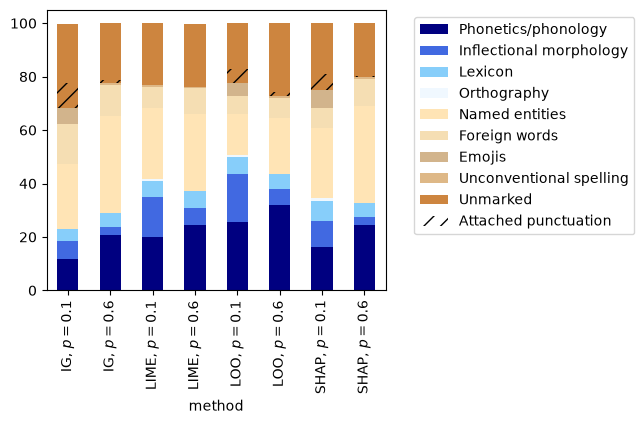

In [28]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

colors = [
    "navy",
    "royalblue",
    "lightskyblue",
    "aliceblue",
    "moccasin",
    "wheat",
    "tan",
    "burlywood",
    "peru",
]

twitter_nonshib_df[[ 'phon_p', 'morph-f_p',  'lex_p', 'orth_p', 'named entity_p',  'foreign_p', 'emoji_p', 'spel_p', 'unm_p']].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
)

# Determine where the hatch starts
d_bottom = twitter_nonshib_df[['emoji_p', 'foreign_p', 'lex_p', 'morph-f_p', 'named entity_p', 'phon_p', 'spel_p', 'orth_p']].sum(axis=1)

# Overlay the hatch
ax.bar(
    range(len(twitter_nonshib_df)),
    twitter_nonshib_df["punct_p"],
    bottom=d_bottom,
    color="none",
    width=0.5, 
    edgecolor="black",
    hatch="//",
    linewidth=0,
    label="punct_p",
)


handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles, 
    ['Phonetics/phonology', 'Inflectional morphology', 'Lexicon', 'Orthography', 'Named entities', 'Foreign words',  'Emojis', 'Unconventional spelling', 'Unmarked', 'Attached punctuation'], 
    loc='upper left', bbox_to_anchor=(0.75, 0.93), bbox_transform=plt.gcf().transFigure)
plt.tight_layout()
plt.show()
fig.figure.savefig('bcms_twitter_nonshib.pdf', bbox_inches='tight')